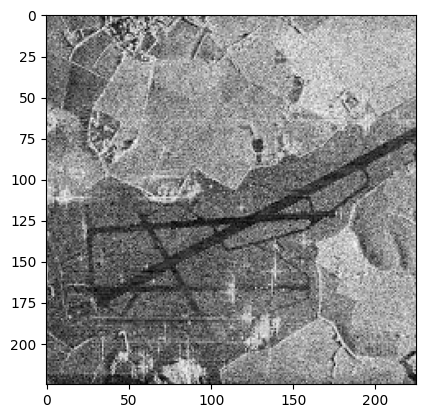

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('sar_3.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")

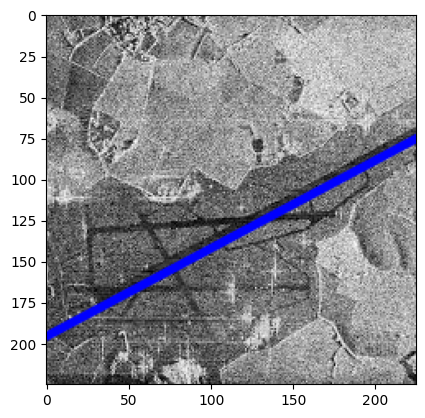

In [25]:
#1. Наиболее протяженный участок
canny = cv2.Canny(image_gray, 130, 400, apertureSize=3)

lines = cv2.HoughLines(canny, 1, np.pi / 180, 120)

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(image_rgb, pt1, pt2, (0, 0 , 255), 3, cv2.LINE_AA)

plt.imshow(image_rgb)

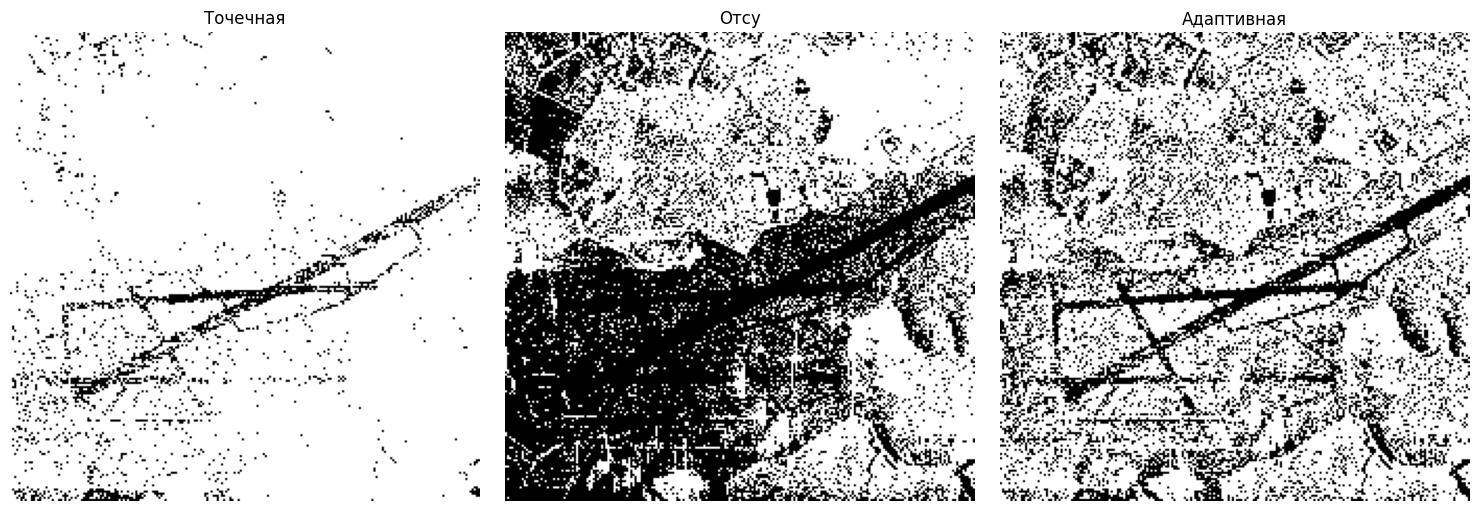

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Точечная бинаризация
bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255
axes[0].imshow(bin_img, cmap="gray")
axes[0].set_title("Точечная")
axes[0].axis("off")

# 2. Метод Отсу
_, th2 = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
axes[1].imshow(th2, cmap="gray")
axes[1].set_title("Отсу")
axes[1].axis("off")

# 3. Адаптивная бинаризация
th3 = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                            cv2.THRESH_BINARY, 71, 21)
axes[2].imshow(th3, cmap="gray")
axes[2].set_title("Адаптивная")
axes[2].axis("off")

plt.tight_layout()
plt.show()